In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

#CALCULATING R2 FOR NAIVE MODEL (PREVIOUS MEDALS) FOR 2021 AND 2024


df = pd.read_csv('dataset_thesis_new_hdi_v8.csv')
df = df.sort_values(['iso_code_mapped', 'year'])


olympic_years = [1996, 2000, 2004, 2008, 2012, 2016, 2021, 2024]
oly = df[df['year'].isin(olympic_years)].copy()
oly = oly.sort_values(['iso_code_mapped', 'year'])

oly['Prev_Total_Medals'] = oly.groupby('iso_code_mapped')['Total'].shift(1)
oly['Prev_Total_Medals'] = oly['Prev_Total_Medals'].fillna(0)


oly_clean = oly.dropna(subset=['Total']).copy()

features = ['Prev_Total_Medals']

# ==========================================
# 1. NAIVE MODEL FOR 2021
# ==========================================
train_2021 = oly_clean[oly_clean['year'] < 2021]
test_2021 = oly_clean[oly_clean['year'] == 2021]

X_train_21 = train_2021[features]
y_train_21 = train_2021['Total']
X_test_21 = test_2021[features]
y_test_21 = test_2021['Total']

rf_21 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_21.fit(X_train_21, y_train_21)
pred_21 = rf_21.predict(X_test_21)

r2_2021 = r2_score(y_test_21, pred_21)
mae_2021 = mean_absolute_error(y_test_21, pred_21)

# ==========================================
# 2. NAIVE MODEL FOR 2024
# ==========================================
train_2024 = oly_clean[oly_clean['year'] < 2024]
test_2024 = oly_clean[oly_clean['year'] == 2024]

X_train_24 = train_2024[features]
y_train_24 = train_2024['Total']
X_test_24 = test_2024[features]
y_test_24 = test_2024['Total']

rf_24 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_24.fit(X_train_24, y_train_24)
pred_24 = rf_24.predict(X_test_24)

r2_2024 = r2_score(y_test_24, pred_24)
mae_2024 = mean_absolute_error(y_test_24, pred_24)

print(f"--- 2021 NAIVE BASELINE ---")
print(f"R2:  {r2_2021:.3f}")
print(f"MAE: {mae_2021:.3f} medals\n")

print(f"--- 2024 NAIVE BASELINE ---")
print(f"R2:  {r2_2024:.3f}")
print(f"MAE: {mae_2024:.3f} medals")

--- 2021 NAIVE BASELINE ---
R2:  0.924
MAE: 2.132 medals

--- 2024 NAIVE BASELINE ---
R2:  0.768
MAE: 2.331 medals


In [1]:
#TESTS TO COMPARE THE MODELS
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from scipy import stats


df = pd.read_csv('dataset_thesis_new_hdi_v8.csv')

# --- DATA PREP ---
team_2024_data = {
    'USA': 592, 'FRA': 573, 'AUS': 460, 'GBR': 327, 'CHN': 388, 'DEU': 428, 'JPN': 403,
    'ITA': 371, 'ESP': 383, 'CAN': 315, 'NLD': 258, 'BRA': 277, 'KOR': 141, 'NZL': 195,
    'HUN': 170, 'ZAF': 138, 'MEX': 107, 'UKR': 140, 'CUB': 61, 'POL': 210, 'CHE': 127,
    'SWE': 117, 'BEL': 165, 'IRL': 133, 'ARG': 136, 'UZB': 86, 'IRN': 40, 'KAZ': 79,
    'KEN': 72, 'JAM': 58, 'ETH': 34, 'NOR': 107, 'DNK': 124, 
    'RUS': 335, 'BLR': 101  
}
for iso, size in team_2024_data.items():
    df.loc[(df['iso_code_mapped'] == iso) & (df['year'] == 2024), 'Team_Size'] = size
    
df = df.sort_values(['iso_code_mapped', 'year'])
df['Team_Size'] = df.groupby('iso_code_mapped')['Team_Size'].ffill()

# 2024 Russia/Belarus Medal Override 
df.loc[(df['iso_code_mapped'] == 'RUS') & (df['year'] == 2024), 'Total'] = 71
df.loc[(df['iso_code_mapped'] == 'BLR') & (df['year'] == 2024), 'Total'] = 7

# LOCF
for col in ['hdi', 'gdi', 'population', 'GDP_merged', 'perc_athletic_prime']:
    df[col] = df.groupby('iso_code_mapped')[col].ffill()

# Lags
for col in ['GDP_merged', 'population', 'hdi', 'gdi', 'perc_athletic_prime']:
    df[f'{col}_t_1'] = df.groupby('iso_code_mapped')[col].shift(1)

df['GDP_t_4'] = df.groupby('iso_code_mapped')['GDP_merged'].shift(4)
df['GDP_Growth_Cycle'] = ((df['GDP_merged_t_1'] - df['GDP_t_4']) / df['GDP_t_4']) * 100

olympic_years = [1996, 2000, 2004, 2008, 2012, 2016, 2021, 2024]
oly = df[df['year'].isin(olympic_years)].copy()
oly = oly.sort_values(['iso_code_mapped', 'year'])

oly['Lagged_Team_Size'] = oly.groupby('iso_code_mapped')['Team_Size'].shift(1)
oly['Prev_Total_Medals'] = oly.groupby('iso_code_mapped')['Total'].shift(1)

oly['Log_GDP_t_1'] = np.log10(oly['GDP_merged_t_1'])
oly['Log_Pop_t_1'] = np.log10(oly['population_t_1'])

final_features = [
    'Log_GDP_t_1', 'Log_Pop_t_1', 'GDP_Growth_Cycle', 
    'perc_athletic_prime_t_1', 'Lagged_Team_Size', 'Prev_Total_Medals', 
    'hdi_t_1', 'gdi_t_1', 'Is_Host'
]

for f in final_features:
    if f in ['Lagged_Team_Size', 'Prev_Total_Medals', 'Is_Host']:
        oly[f] = oly[f].fillna(0)
    else:
        oly[f] = oly[f].fillna(oly[f].mean())

# Drop NAs
oly_clean = oly.dropna(subset=['Total']).copy()

# Filter for 2024 testing
train_df = oly_clean[oly_clean['year'] < 2024]
test_df = oly_clean[oly_clean['year'] == 2024]

y_train = train_df['Total']
y_test = test_df['Total']

# --- MODEL 1: NAIVE (Only Prev_Total_Medals) ---
X_train_naive = train_df[['Prev_Total_Medals']]
X_test_naive = test_df[['Prev_Total_Medals']]

rf_naive = RandomForestRegressor(n_estimators=100, random_state=42)
rf_naive.fit(X_train_naive, y_train)
preds_naive = rf_naive.predict(X_test_naive)

# --- MODEL 2: COMPLETE ---
X_train_comp = train_df[final_features]
X_test_comp = test_df[final_features]

rf_comp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_comp.fit(X_train_comp, y_train)
preds_comp = rf_comp.predict(X_test_comp)

# --- CALCULATE ERRORS ---
errors_naive = np.abs(y_test - preds_naive)
errors_comp = np.abs(y_test - preds_comp)

# --- STATISTICAL TESTS ---
# Paired t-test
t_stat, p_val_t = stats.ttest_rel(errors_naive, errors_comp)

# Wilcoxon signed-rank test (better for non-normal errors like Olympic medals)
w_stat, p_val_w = stats.wilcoxon(errors_naive, errors_comp)

print(f"Naive R2: {r2_score(y_test, preds_naive):.4f}")
print(f"Complete R2: {r2_score(y_test, preds_comp):.4f}")
print(f"Naive Mean Absolute Error: {errors_naive.mean():.4f}")
print(f"Complete Mean Absolute Error: {errors_comp.mean():.4f}\n")

print(f"Paired T-Test p-value: {p_val_t:.5f}")
print(f"Wilcoxon Signed-Rank p-value: {p_val_w:.5f}")

Naive R2: 0.9328
Complete R2: 0.9659
Naive Mean Absolute Error: 1.9961
Complete Mean Absolute Error: 1.3735

Paired T-Test p-value: 0.00000
Wilcoxon Signed-Rank p-value: 0.00000


R2 Score (No History Model - 2024 Test): 0.8710

Feature Importance (Excluding Prev_Total_Medals):
                Feature  Importance      Std
       Lagged_Team_Size    1.214021 0.126648
            Log_Pop_t_1    0.185224 0.026974
            Log_GDP_t_1    0.066475 0.004959
                Is_Host    0.047514 0.024498
                hdi_t_1    0.028861 0.006351
                gdi_t_1    0.022318 0.010646
perc_athletic_prime_t_1    0.009002 0.006341
       GDP_Growth_Cycle    0.001776 0.012881


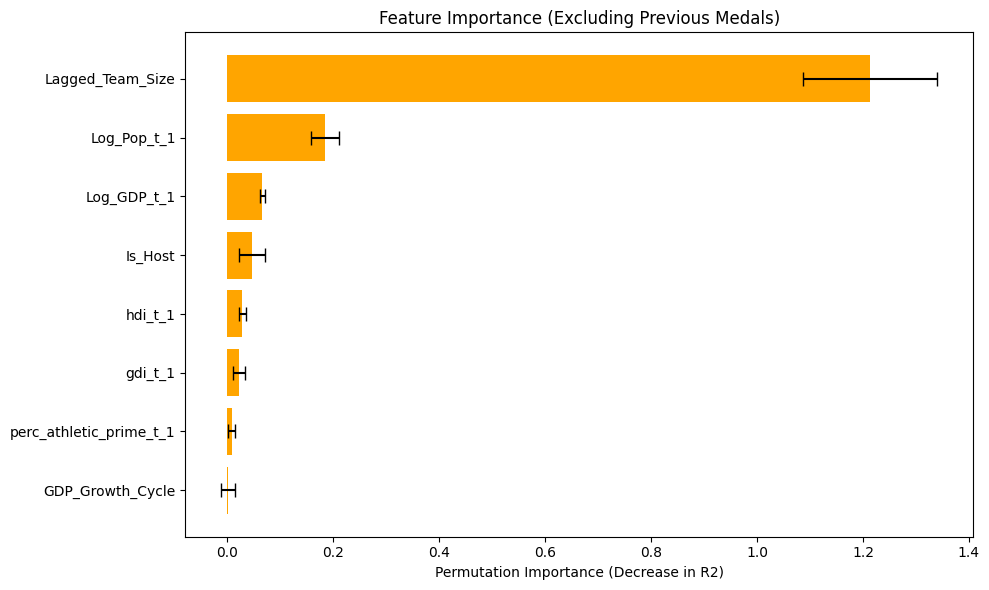

In [4]:
#MODEL WITHOUT PREVIOUS MEDALS TO ASSESS FEATURE IMPORTANCE


import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('dataset_thesis_new_hdi_v8.csv')

#  2024 Team Sizes 
team_2024_data = {
    'USA': 592, 'FRA': 573, 'AUS': 460, 'GBR': 327, 'CHN': 388, 'DEU': 428, 'JPN': 403,
    'ITA': 371, 'ESP': 383, 'CAN': 315, 'NLD': 258, 'BRA': 277, 'KOR': 141, 'NZL': 195,
    'HUN': 170, 'ZAF': 138, 'MEX': 107, 'UKR': 140, 'CUB': 61, 'POL': 210, 'CHE': 127,
    'SWE': 117, 'BEL': 165, 'IRL': 133, 'ARG': 136, 'UZB': 86, 'IRN': 40, 'KAZ': 79,
    'KEN': 72, 'JAM': 58, 'ETH': 34, 'NOR': 107, 'DNK': 124, 
    'RUS': 335, 'BLR': 101  
}

for iso, size in team_2024_data.items():
    df.loc[(df['iso_code_mapped'] == iso) & (df['year'] == 2024), 'Team_Size'] = size

# Fix RUS and BLR 2021 Team Size (to make 2024 lag accurate)
df.loc[(df['iso_code_mapped'] == 'RUS') & (df['year'] == 2021), 'Team_Size'] = 335
df.loc[(df['iso_code_mapped'] == 'BLR') & (df['year'] == 2021), 'Team_Size'] = 101

df = df.sort_values(['iso_code_mapped', 'year'])
df['Team_Size'] = df.groupby('iso_code_mapped')['Team_Size'].ffill()

#  Create lags and features
for col in ['hdi', 'gdi', 'population', 'GDP_merged', 'perc_athletic_prime']:
    df[col] = df.groupby('iso_code_mapped')[col].ffill()
    df[f'{col}_t_1'] = df.groupby('iso_code_mapped')[col].shift(1)

df['GDP_t_4'] = df.groupby('iso_code_mapped')['GDP_merged'].shift(4)
df['GDP_Growth_Cycle'] = ((df['GDP_merged_t_1'] - df['GDP_t_4']) / df['GDP_t_4']) * 100

olympic_years = [1996, 2000, 2004, 2008, 2012, 2016, 2021, 2024]
oly = df[df['year'].isin(olympic_years)].copy()
oly = oly.sort_values(['iso_code_mapped', 'year'])

oly['Lagged_Team_Size'] = oly.groupby('iso_code_mapped')['Team_Size'].shift(1)
oly['Prev_Total_Medals'] = oly.groupby('iso_code_mapped')['Total'].shift(1)

oly['Log_GDP_t_1'] = np.log10(oly['GDP_merged_t_1'])
oly['Log_Pop_t_1'] = np.log10(oly['population_t_1'])

# Feature set EXCLUDING Prev_Total_Medals
features_no_history = [
    'Log_GDP_t_1', 'Log_Pop_t_1', 'GDP_Growth_Cycle', 
    'perc_athletic_prime_t_1', 'Lagged_Team_Size', 
    'hdi_t_1', 'gdi_t_1', 'Is_Host'
]

# Impute
for f in features_no_history + ['Prev_Total_Medals']:
    if f in ['Lagged_Team_Size', 'Prev_Total_Medals', 'Is_Host']:
        oly[f] = oly[f].fillna(0)
    else:
        oly[f] = oly[f].fillna(oly[f].mean())

# Filter for test year 2024
oly_clean = oly.dropna(subset=['Total', 'Log_GDP_t_1']).copy()
train = oly_clean[oly_clean['year'] < 2024]
test = oly_clean[oly_clean['year'] == 2024]

# Train Model (No History)
rf_no_hist = RandomForestRegressor(n_estimators=100, random_state=42)
rf_no_hist.fit(train[features_no_history], train['Total'])
pred_no_hist = rf_no_hist.predict(test[features_no_history])
r2_no_hist = r2_score(test['Total'], pred_no_hist)

# Permutation Importance
perm = permutation_importance(rf_no_hist, test[features_no_history], test['Total'], n_repeats=30, random_state=42, n_jobs=-1)
imp = pd.DataFrame({
    'Feature': features_no_history,
    'Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Importance', ascending=False)

print(f"R2 Score (No History Model - 2024 Test): {r2_no_hist:.4f}")
print("\nFeature Importance (Excluding Prev_Total_Medals):")
print(imp.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
imp_sorted = imp.sort_values('Importance', ascending=True)
plt.barh(imp_sorted['Feature'], imp_sorted['Importance'], xerr=imp_sorted['Std'], color='orange', capsize=5)
plt.title('Feature Importance (Excluding Previous Medals)')
plt.xlabel('Permutation Importance (Decrease in R2)')
plt.tight_layout()
plt.savefig('importance_no_history.png')

R2 Score (No History Model - 2024 Test): 0.7737

Feature Importance (Excluding Prev_Total_Medals):
                Feature  Importance      Std
            Log_GDP_t_1    1.012274 0.097496
            Log_Pop_t_1    0.124558 0.044221
perc_athletic_prime_t_1    0.078057 0.028688
                gdi_t_1    0.061663 0.014898
                hdi_t_1    0.045534 0.015807
                Is_Host    0.044731 0.023133
       GDP_Growth_Cycle    0.011102 0.005817


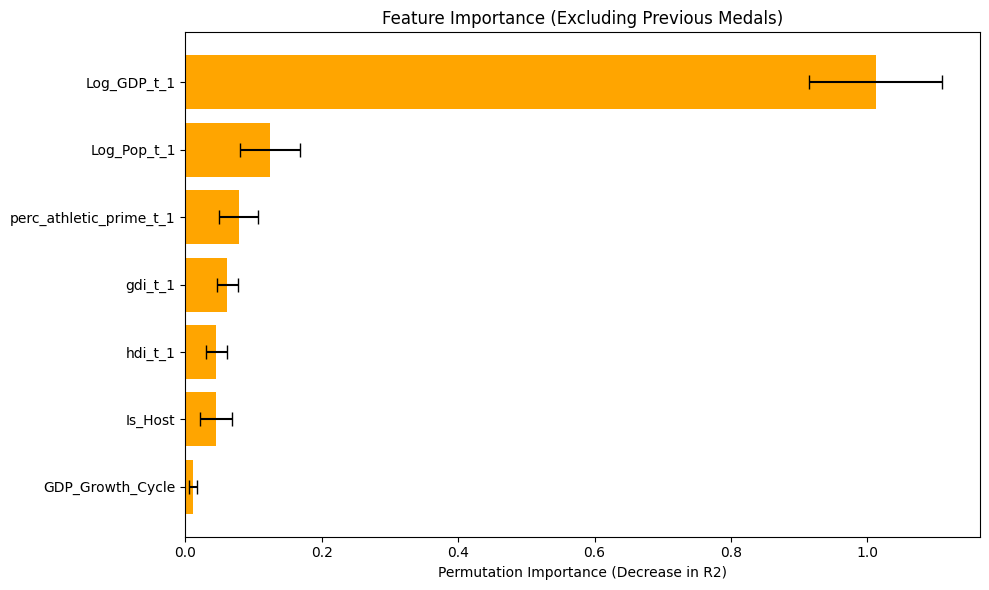

In [6]:
#MODEL WITHOUT PREVIOUS MEDALS AND TEAM SIZE TO ASSESS FEATURE IMPORTANCE


import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('dataset_thesis_new_hdi_v8.csv')

#  2024 Team Sizes 
team_2024_data = {
    'USA': 592, 'FRA': 573, 'AUS': 460, 'GBR': 327, 'CHN': 388, 'DEU': 428, 'JPN': 403,
    'ITA': 371, 'ESP': 383, 'CAN': 315, 'NLD': 258, 'BRA': 277, 'KOR': 141, 'NZL': 195,
    'HUN': 170, 'ZAF': 138, 'MEX': 107, 'UKR': 140, 'CUB': 61, 'POL': 210, 'CHE': 127,
    'SWE': 117, 'BEL': 165, 'IRL': 133, 'ARG': 136, 'UZB': 86, 'IRN': 40, 'KAZ': 79,
    'KEN': 72, 'JAM': 58, 'ETH': 34, 'NOR': 107, 'DNK': 124, 
    'RUS': 335, 'BLR': 101  
}

for iso, size in team_2024_data.items():
    df.loc[(df['iso_code_mapped'] == iso) & (df['year'] == 2024), 'Team_Size'] = size

# Fix RUS and BLR 2021 Team Size (to make 2024 lag accurate)
df.loc[(df['iso_code_mapped'] == 'RUS') & (df['year'] == 2021), 'Team_Size'] = 335
df.loc[(df['iso_code_mapped'] == 'BLR') & (df['year'] == 2021), 'Team_Size'] = 101

df = df.sort_values(['iso_code_mapped', 'year'])
df['Team_Size'] = df.groupby('iso_code_mapped')['Team_Size'].ffill()

#  Create lags and features
for col in ['hdi', 'gdi', 'population', 'GDP_merged', 'perc_athletic_prime']:
    df[col] = df.groupby('iso_code_mapped')[col].ffill()
    df[f'{col}_t_1'] = df.groupby('iso_code_mapped')[col].shift(1)

df['GDP_t_4'] = df.groupby('iso_code_mapped')['GDP_merged'].shift(4)
df['GDP_Growth_Cycle'] = ((df['GDP_merged_t_1'] - df['GDP_t_4']) / df['GDP_t_4']) * 100

olympic_years = [1996, 2000, 2004, 2008, 2012, 2016, 2021, 2024]
oly = df[df['year'].isin(olympic_years)].copy()
oly = oly.sort_values(['iso_code_mapped', 'year'])

oly['Lagged_Team_Size'] = oly.groupby('iso_code_mapped')['Team_Size'].shift(1)
oly['Prev_Total_Medals'] = oly.groupby('iso_code_mapped')['Total'].shift(1)

oly['Log_GDP_t_1'] = np.log10(oly['GDP_merged_t_1'])
oly['Log_Pop_t_1'] = np.log10(oly['population_t_1'])

# Feature set EXCLUDING Prev_Total_Medals AND Lagged_Team_Size
features_no_history = [
    'Log_GDP_t_1', 'Log_Pop_t_1', 'GDP_Growth_Cycle', 
    'perc_athletic_prime_t_1', 
    'hdi_t_1', 'gdi_t_1', 'Is_Host'
]

# Impute
for f in features_no_history + ['Prev_Total_Medals']:
    if f in ['Lagged_Team_Size', 'Prev_Total_Medals', 'Is_Host']:
        oly[f] = oly[f].fillna(0)
    else:
        oly[f] = oly[f].fillna(oly[f].mean())

# Filter for test year 2024
oly_clean = oly.dropna(subset=['Total', 'Log_GDP_t_1']).copy()
train = oly_clean[oly_clean['year'] < 2024]
test = oly_clean[oly_clean['year'] == 2024]

# Train Model (No History AND No Team Size)
rf_no_hist = RandomForestRegressor(n_estimators=100, random_state=42)
rf_no_hist.fit(train[features_no_history], train['Total'])
pred_no_hist = rf_no_hist.predict(test[features_no_history])
r2_no_hist = r2_score(test['Total'], pred_no_hist)

# Permutation Importance
perm = permutation_importance(rf_no_hist, test[features_no_history], test['Total'], n_repeats=30, random_state=42, n_jobs=-1)
imp = pd.DataFrame({
    'Feature': features_no_history,
    'Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Importance', ascending=False)

print(f"R2 Score (No History Model - 2024 Test): {r2_no_hist:.4f}")
print("\nFeature Importance (Excluding Prev_Total_Medals):")
print(imp.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
imp_sorted = imp.sort_values('Importance', ascending=True)
plt.barh(imp_sorted['Feature'], imp_sorted['Importance'], xerr=imp_sorted['Std'], color='orange', capsize=5)
plt.title('Feature Importance (Excluding Previous Medals)')
plt.xlabel('Permutation Importance (Decrease in R2)')
plt.tight_layout()
plt.savefig('importance_no_history.png')